In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("customer_segmentation.csv", sep="\t")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 2240
Number of Columns: 29


In [5]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns in the dataset:

1 - ID
2 - Year_Birth
3 - Education
4 - Marital_Status
5 - Income
6 - Kidhome
7 - Teenhome
8 - Dt_Customer
9 - Recency
10 - MntWines
11 - MntFruits
12 - MntMeatProducts
13 - MntFishProducts
14 - MntSweetProducts
15 - MntGoldProds
16 - NumDealsPurchases
17 - NumWebPurchases
18 - NumCatalogPurchases
19 - NumStorePurchases
20 - NumWebVisitsMonth
21 - AcceptedCmp3
22 - AcceptedCmp4
23 - AcceptedCmp5
24 - AcceptedCmp1
25 - AcceptedCmp2
26 - Complain
27 - Z_CostContact
28 - Z_Revenue
29 - Response


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values[missing_values > 0])

Missing values in each column:

Income    24
dtype: int64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (2240, 29)


In [11]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing Income values:", df["Income"].isnull().sum())

Missing Income values: 0


In [12]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y",
    errors="coerce"
)

print(df["Dt_Customer"].head())

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [13]:
current_year = 2015

df["Age"] = current_year - df["Year_Birth"]

df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,58
1,1954,61
2,1965,50
3,1984,31
4,1981,34


In [14]:
print(df["Age"].describe())

count    2240.000000
mean       46.194196
std        11.984069
min        19.000000
25%        38.000000
50%        45.000000
75%        56.000000
max       122.000000
Name: Age, dtype: float64


In [15]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

print("Dataset shape after age filtering:", df.shape)

Dataset shape after age filtering: (2237, 30)


In [17]:
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)

df[["Total_Spending"]].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [18]:
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_columns].sum(axis=1)

df[["Total_Purchases"]].head()

,Total_Purchases
0,22
1,4
2,20
3,6
4,14


In [19]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

df[["Kidhome", "Teenhome", "Total_Children"]].head()

,Kidhome,Teenhome,Total_Children
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1


In [20]:
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

df["Total_Campaign_Response"] = df[campaign_columns].sum(axis=1)

df[["Total_Campaign_Response"]].head()

,Total_Campaign_Response
0,1
1,0
2,0
3,0
4,0


In [21]:
df[
    [
        "Age",
        "Income",
        "Total_Spending",
        "Total_Purchases",
        "Total_Children",
        "NumWebVisitsMonth",
        "Recency"
    ]
].head()

,Age,Income,Total_Spending,Total_Purchases,Total_Children,NumWebVisitsMonth,Recency
0,58,58138.0,1617,22,0,7,58
1,61,46344.0,27,4,2,5,38
2,50,71613.0,776,20,0,4,26
3,31,26646.0,53,6,1,6,26
4,34,58293.0,422,14,1,5,94


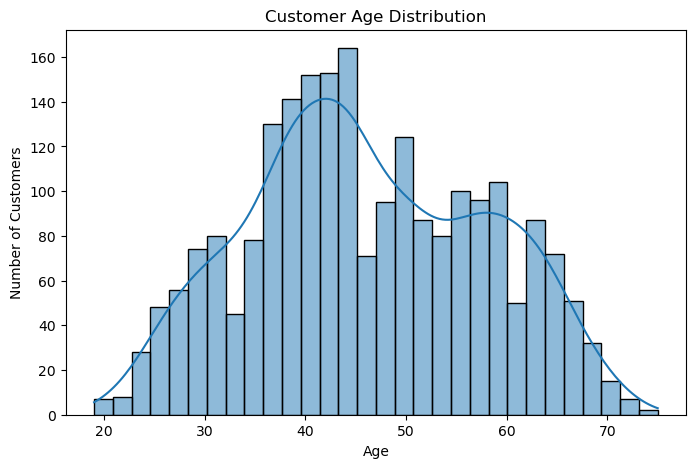

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

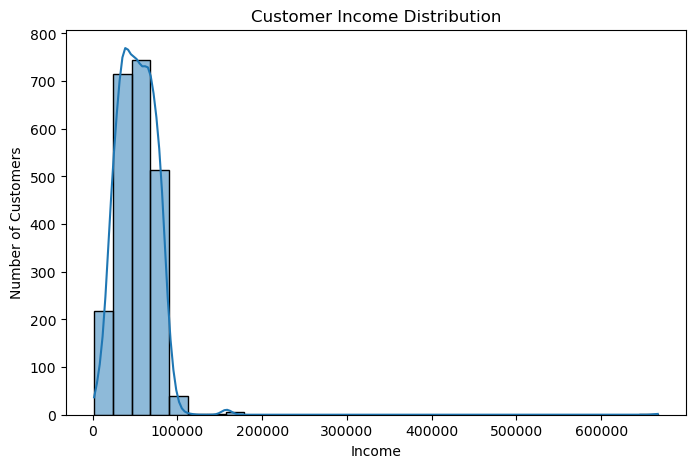

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Income"], bins=30, kde=True)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

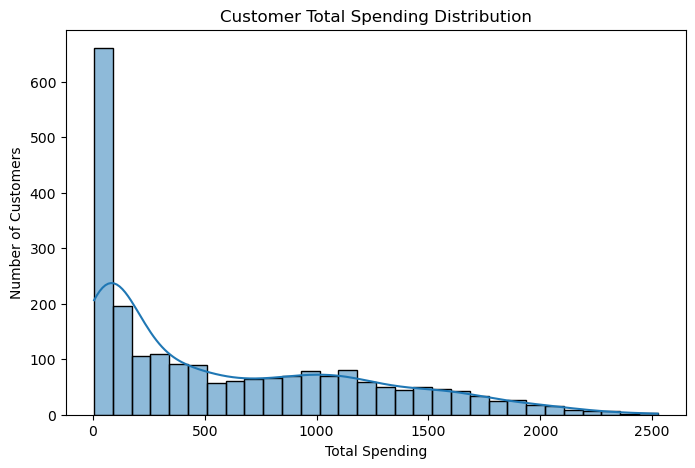

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Total_Spending"], bins=30, kde=True)

plt.title("Customer Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

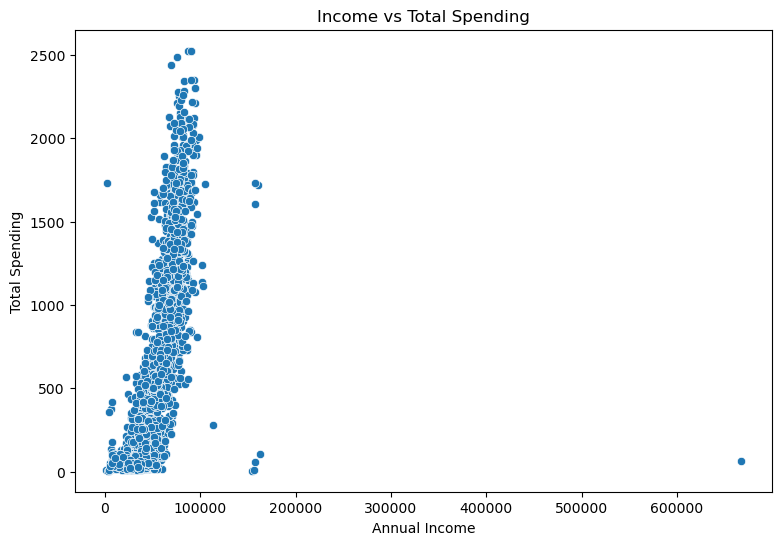

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending"
)

plt.title("Income vs Total Spending")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")

plt.show()

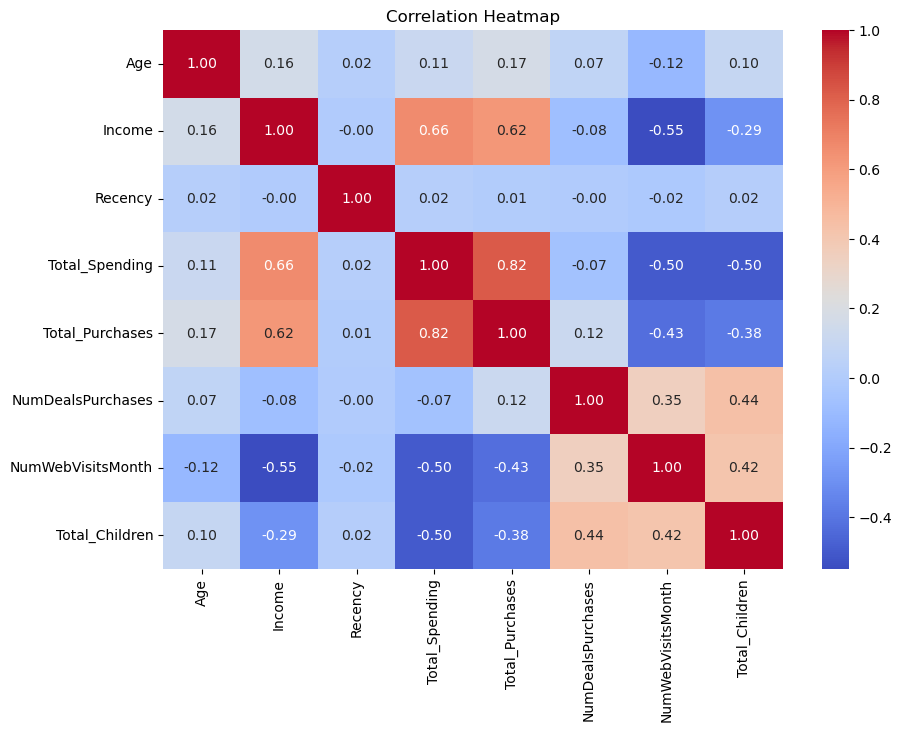

In [26]:
correlation_features = [
    "Age",
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth",
    "Total_Children"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[correlation_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
features = [
    "Age",
    "Income",
    "Recency",
    "Total_Spending",
    "Total_Purchases",
    "NumDealsPurchases",
    "NumWebVisitsMonth"
]

X = df[features].copy()

X.head()

,Age,Income,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth
0,58,58138.0,58,1617,22,3,7
1,61,46344.0,38,27,4,2,5
2,50,71613.0,26,776,20,1,4
3,31,26646.0,26,53,6,2,6
4,34,58293.0,94,422,14,5,5


In [28]:
print("Features used for clustering:")
print(features)

print("\nShape of clustering data:", X.shape)

Features used for clustering:
['Age', 'Income', 'Recency', 'Total_Spending', 'Total_Purchases', 'NumDealsPurchases', 'NumWebVisitsMonth']

Shape of clustering data: (2237, 7)


In [29]:
print(X.isnull().sum())

Age                  0
Income               0
Recency              0
Total_Spending       0
Total_Purchases      0
NumDealsPurchases    0
NumWebVisitsMonth    0
dtype: int64


In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Age,Income,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth
0,1.017296,0.236068,0.307272,1.680649,1.312543,0.348371,0.692882
1,1.273722,-0.234982,-0.383584,-0.961838,-1.185961,-0.169096,-0.131574
2,0.333495,0.774257,-0.798098,0.282956,1.034932,-0.686563,-0.543802
3,-1.290534,-1.021717,-0.798098,-0.918627,-0.908350,-0.169096,0.280654
4,-1.034108,0.242259,1.550812,-0.305371,0.202097,1.383304,-0.131574


In [31]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

print(wcss)

[15658.999999999993, 10688.43715693666, 9116.109799949383, 8275.410786558874, 7559.905207874721, 7077.6762733289415, 6619.063745731906, 6049.3895516213715, 5696.9211809793305, 5426.261313527778]


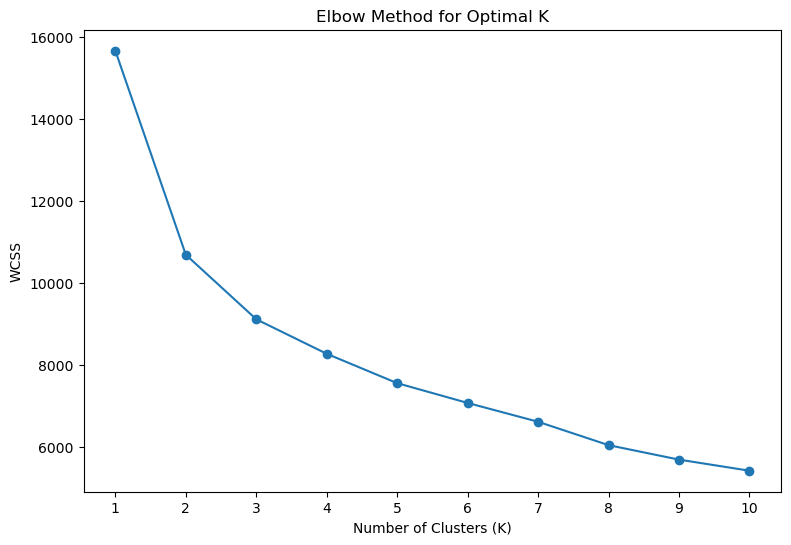

In [32]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1, 11))

plt.show()

In [33]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3100
K = 3, Silhouette Score = 0.2785
K = 4, Silhouette Score = 0.2208
K = 5, Silhouette Score = 0.1957
K = 6, Silhouette Score = 0.1892
K = 7, Silhouette Score = 0.1880
K = 8, Silhouette Score = 0.1907
K = 9, Silhouette Score = 0.1932
K = 10, Silhouette Score = 0.1825


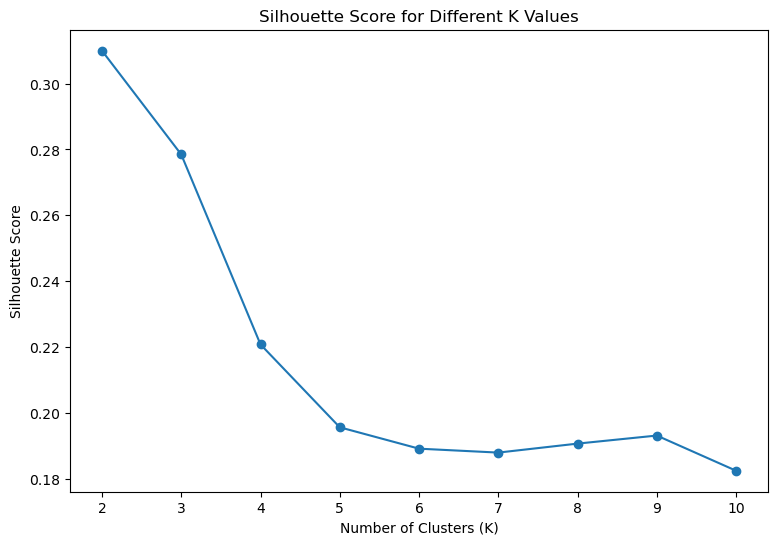

In [34]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))

plt.show()

In [35]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")

K-Means model trained successfully!


In [36]:
df["Cluster"] = clusters

df[[
    "ID",
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Cluster"
]].head(10)

,ID,Age,Income,Total_Spending,Total_Purchases,Cluster
0,5524,58,58138.0,1617,22,1
1,2174,61,46344.0,27,4,0
2,4141,50,71613.0,776,20,1
3,6182,31,26646.0,53,6,0
4,5324,34,58293.0,422,14,2
5,7446,48,62513.0,716,20,1
6,965,44,55635.0,590,17,2
7,6177,30,33454.0,169,8,0
8,4855,41,30351.0,46,5,0
9,5899,65,5648.0,49,1,3


In [37]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    569
1    778
2    369
3    521
Name: count, dtype: int64


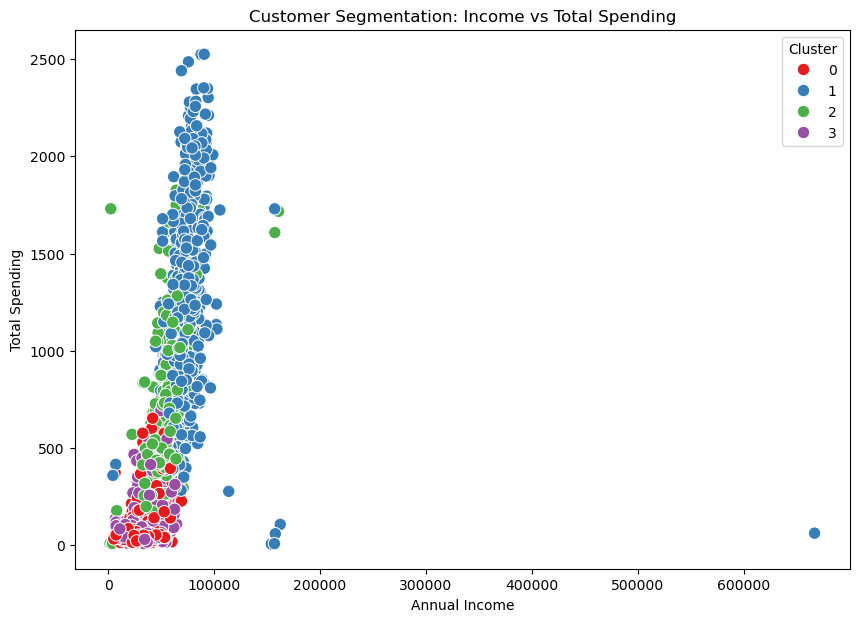

In [38]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segmentation: Income vs Total Spending")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

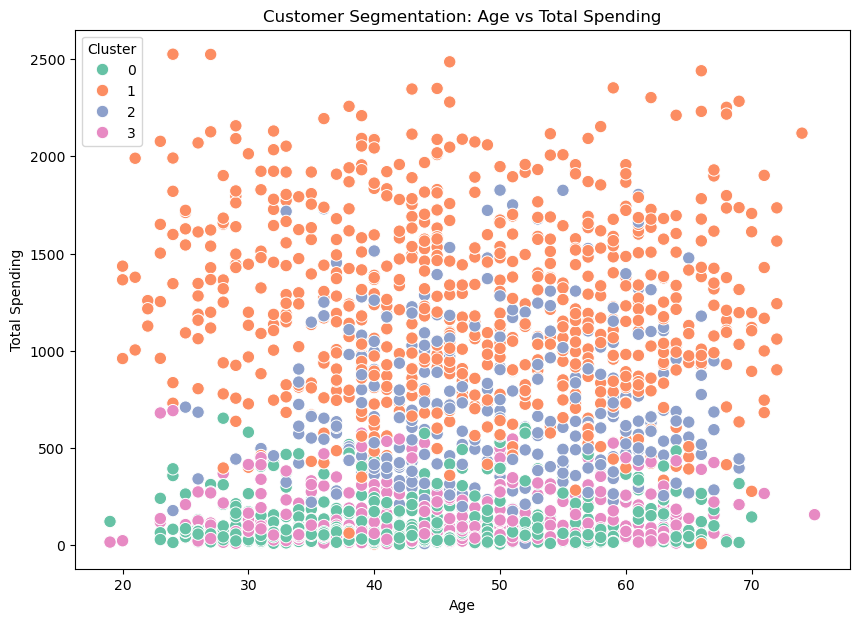

In [39]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Spending",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation: Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.legend(title="Cluster")

plt.show()

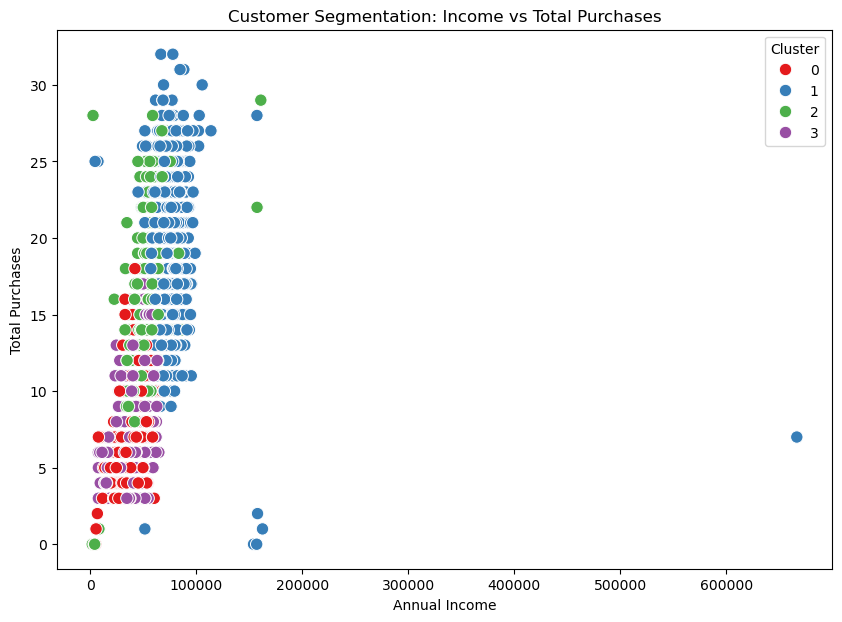

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Purchases",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segmentation: Income vs Total Purchases")
plt.xlabel("Annual Income")
plt.ylabel("Total Purchases")
plt.legend(title="Cluster")

plt.show()

In [41]:
cluster_profile = df.groupby("Cluster")[
    [
        "Age",
        "Income",
        "Recency",
        "Total_Spending",
        "Total_Purchases",
        "NumDealsPurchases",
        "NumWebVisitsMonth",
        "Total_Children"
    ]
].mean().round(2)

cluster_profile

,Age,Income,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Total_Children
Cluster,,,,,,,,
0,42.33,34573.51,24.88,114.88,6.18,1.87,6.49,1.15
1,47.69,74562.77,49.48,1239.14,19.27,1.40,3.17,0.41
2,49.66,54131.57,47.60,698.70,16.49,5.49,6.73,1.38
3,45.32,36806.14,76.08,130.15,6.65,1.96,6.26,1.23


In [42]:
cluster_size = df.groupby("Cluster").size().reset_index(name="Customer_Count")

cluster_size

,Cluster,Customer_Count
0,0,569
1,1,778
2,2,369
3,3,521


In [43]:
cluster_analysis = cluster_profile.copy()

cluster_analysis["Customer_Count"] = (
    df["Cluster"].value_counts().sort_index()
)

cluster_analysis

,Age,Income,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Total_Children,Customer_Count
Cluster,,,,,,,,,
0,42.33,34573.51,24.88,114.88,6.18,1.87,6.49,1.15,569
1,47.69,74562.77,49.48,1239.14,19.27,1.40,3.17,0.41,778
2,49.66,54131.57,47.60,698.70,16.49,5.49,6.73,1.38,369
3,45.32,36806.14,76.08,130.15,6.65,1.96,6.26,1.23,521


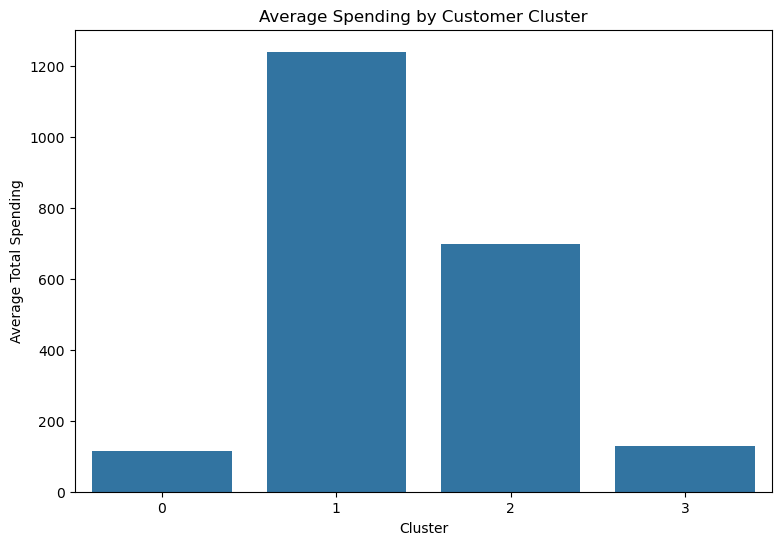

In [44]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_analysis.index,
    y=cluster_analysis["Total_Spending"]
)

plt.title("Average Spending by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")

plt.show()

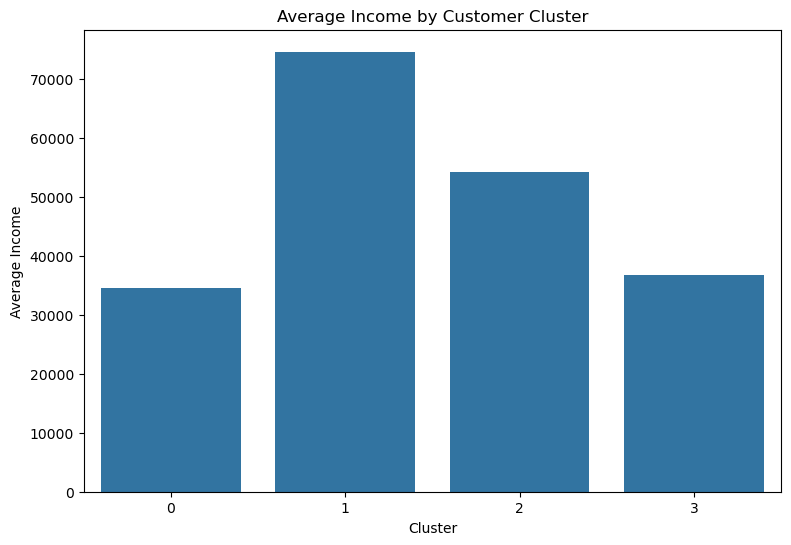

In [45]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_analysis.index,
    y=cluster_analysis["Income"]
)

plt.title("Average Income by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Income")

plt.show()

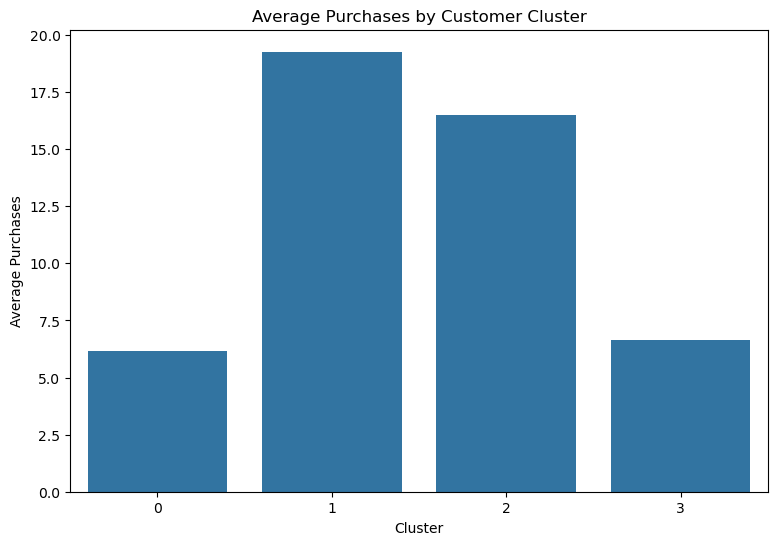

In [46]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_analysis.index,
    y=cluster_analysis["Total_Purchases"]
)

plt.title("Average Purchases by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Purchases")

plt.show()

In [47]:
cluster_analysis[
    [
        "Income",
        "Total_Spending",
        "Total_Purchases",
        "Recency",
        "Customer_Count"
    ]
]

,Income,Total_Spending,Total_Purchases,Recency,Customer_Count
Cluster,,,,,
0,34573.51,114.88,6.18,24.88,569
1,74562.77,1239.14,19.27,49.48,778
2,54131.57,698.70,16.49,47.60,369
3,36806.14,130.15,6.65,76.08,521


In [48]:
segment_names = {
    0: "Budget Customers",
    1: "Premium Customers",
    2: "Regular Customers",
    3: "Potential Customers"
}

df["Customer_Segment"] = df["Cluster"].map(segment_names)

df[
    [
        "ID",
        "Income",
        "Total_Spending",
        "Total_Purchases",
        "Cluster",
        "Customer_Segment"
    ]
].head(20)

,ID,Income,Total_Spending,Total_Purchases,Cluster,Customer_Segment
0,5524,58138.0,1617,22,1,Premium Customers
1,2174,46344.0,27,4,0,Budget Customers
2,4141,71613.0,776,20,1,Premium Customers
3,6182,26646.0,53,6,0,Budget Customers
4,5324,58293.0,422,14,2,Regular Customers
5,7446,62513.0,716,20,1,Premium Customers
6,965,55635.0,590,17,2,Regular Customers
7,6177,33454.0,169,8,0,Budget Customers
8,4855,30351.0,46,5,0,Budget Customers
9,5899,5648.0,49,1,3,Potential Customers


In [49]:
segment_counts = df["Customer_Segment"].value_counts()

print(segment_counts)

Customer_Segment
Premium Customers      778
Budget Customers       569
Potential Customers    521
Regular Customers      369
Name: count, dtype: int64


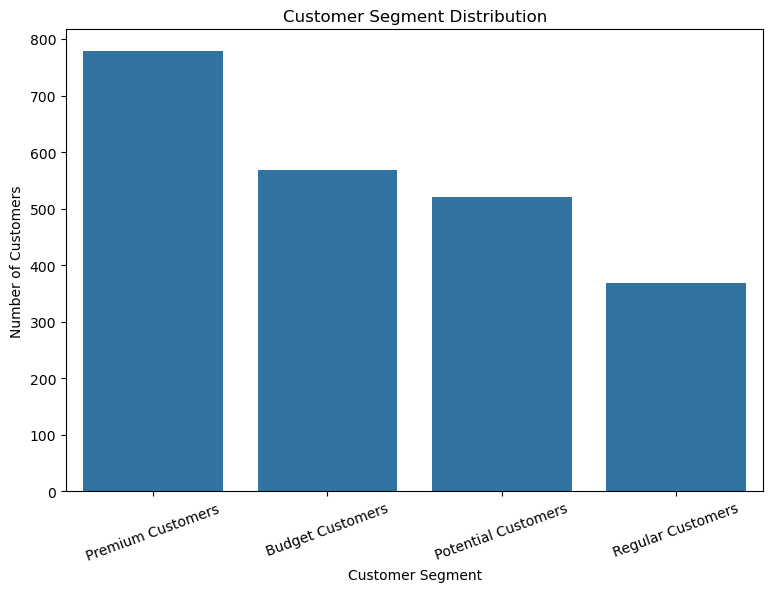

In [50]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

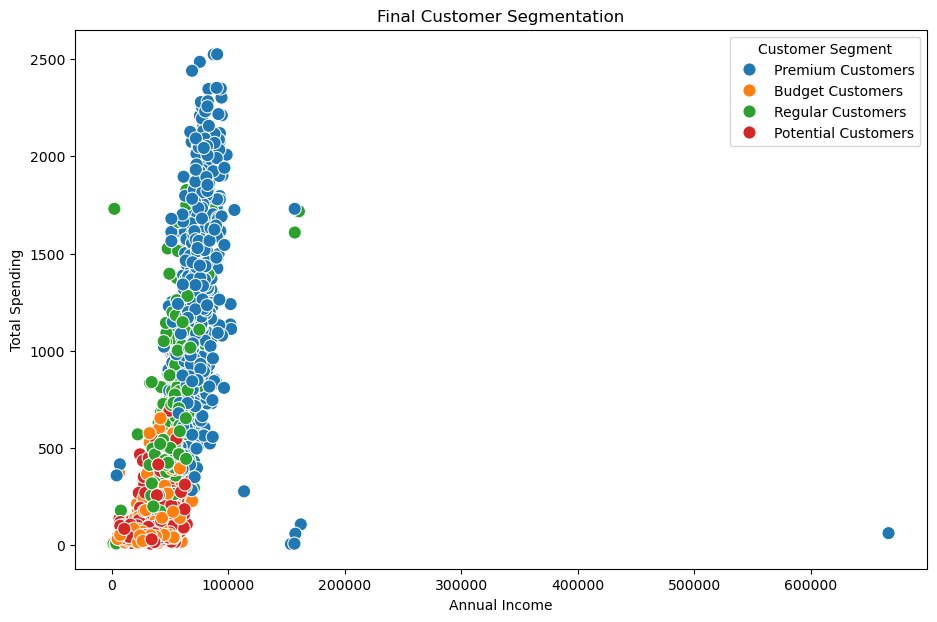

In [51]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Customer_Segment",
    s=90
)

plt.title("Final Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Total Spending")
plt.legend(title="Customer Segment")

plt.show()

In [52]:
final_data = df[
    [
        "ID",
        "Age",
        "Income",
        "Recency",
        "Total_Spending",
        "Total_Purchases",
        "NumDealsPurchases",
        "NumWebVisitsMonth",
        "Customer_Segment"
    ]
]

final_data.head(20)

,ID,Age,Income,Recency,Total_Spending,Total_Purchases,NumDealsPurchases,NumWebVisitsMonth,Customer_Segment
0,5524,58,58138.0,58,1617,22,3,7,Premium Customers
1,2174,61,46344.0,38,27,4,2,5,Budget Customers
2,4141,50,71613.0,26,776,20,1,4,Premium Customers
3,6182,31,26646.0,26,53,6,2,6,Budget Customers
4,5324,34,58293.0,94,422,14,5,5,Regular Customers
5,7446,48,62513.0,16,716,20,2,6,Premium Customers
6,965,44,55635.0,34,590,17,4,6,Regular Customers
7,6177,30,33454.0,32,169,8,2,8,Budget Customers
8,4855,41,30351.0,19,46,5,1,9,Budget Customers
9,5899,65,5648.0,68,49,1,1,20,Potential Customers


In [53]:
final_summary = df.groupby("Customer_Segment").agg(
    Customer_Count=("ID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Income", "mean"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Purchases=("Total_Purchases", "mean"),
    Average_Recency=("Recency", "mean")
).round(2)

final_summary

,Customer_Count,Average_Age,Average_Income,Average_Spending,Average_Purchases,Average_Recency
Customer_Segment,,,,,,
Budget Customers,569,42.33,34573.51,114.88,6.18,24.88
Potential Customers,521,45.32,36806.14,130.15,6.65,76.08
Premium Customers,778,47.69,74562.77,1239.14,19.27,49.48
Regular Customers,369,49.66,54131.57,698.70,16.49,47.60


In [54]:
for segment in final_summary.index:
    
    print("\n" + "=" * 60)
    print("CUSTOMER SEGMENT:", segment)
    print("=" * 60)
    
    print("Number of Customers:",
          int(final_summary.loc[segment, "Customer_Count"]))
    
    print("Average Age:",
          round(final_summary.loc[segment, "Average_Age"], 2))
    
    print("Average Income:",
          round(final_summary.loc[segment, "Average_Income"], 2))
    
    print("Average Spending:",
          round(final_summary.loc[segment, "Average_Spending"], 2))
    
    print("Average Purchases:",
          round(final_summary.loc[segment, "Average_Purchases"], 2))
    
    print("Average Recency:",
          round(final_summary.loc[segment, "Average_Recency"], 2))


CUSTOMER SEGMENT: Budget Customers
Number of Customers: 569
Average Age: 42.33
Average Income: 34573.51
Average Spending: 114.88
Average Purchases: 6.18
Average Recency: 24.88

CUSTOMER SEGMENT: Potential Customers
Number of Customers: 521
Average Age: 45.32
Average Income: 36806.14
Average Spending: 130.15
Average Purchases: 6.65
Average Recency: 76.08

CUSTOMER SEGMENT: Premium Customers
Number of Customers: 778
Average Age: 47.69
Average Income: 74562.77
Average Spending: 1239.14
Average Purchases: 19.27
Average Recency: 49.48

CUSTOMER SEGMENT: Regular Customers
Number of Customers: 369
Average Age: 49.66
Average Income: 54131.57
Average Spending: 698.7
Average Purchases: 16.49
Average Recency: 47.6


In [55]:
df.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

print("Segmented customer dataset saved successfully!")

Segmented customer dataset saved successfully!


In [56]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(
        {
            "model": kmeans,
            "scaler": scaler,
            "features": features
        },
        file
    )

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
